In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append("/home/sambt/CASE_final/CASE_QUAK_final/commonTools/")
import qRegNN_NFs_general as qrnn
import h5py
import os
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
device = torch.device('cuda:0')
from tqdm import tqdm

In [2]:
base = "/nobackup/users/sambt/QR_samples/LHCO/"
f_bb1 = f"{base}/challenge/BB1/merged.h5"
f_ind_bb1 = f"{base}/challenge/BB1/split_indices.h5"
f_rd = f"{base}/rd/RD/merged.h5"
f_ind_rd = f"{base}/rd/RD/split_indices.h5"


fitvars = ['jet1_rho','jet1_tau21','jet1_tau32','jet1_tau43',
           'jet2_rho','jet2_tau21','jet2_tau32','jet2_tau43']

with h5py.File(f_ind_rd,'r') as f:
    rd_test_idx = f['test_inds'][()]
    rd_train_idx = f['train_inds'][()]
    
with h5py.File(f_ind_bb1,'r') as f:
    bb1_test_idx = f['test_inds'][()]
    bb1_train_idx = f['train_inds'][()]
    
with h5py.File(f_bb1,"r") as fp_b1:
    labels_b1 = np.loadtxt(f"{base}/challenge/BB1/events_LHCO2020_BlackBox1.masterkey")
    nev = len(labels_b1)
    b1_test = np.concatenate([fp_b1[v][()][labels_b1==0].reshape(-1,1) for v in fitvars],axis=1)[bb1_test_idx]
    b1_train = np.concatenate([fp_b1[v][()][labels_b1==0].reshape(-1,1) for v in fitvars],axis=1)[bb1_train_idx]
    
with h5py.File(f_rd,"r") as frd:
    label = frd['label'][()]
    mask = label==0
    rd_test = np.concatenate([frd[v][()][mask].reshape(-1,1) for v in fitvars],axis=1)[rd_test_idx]
    rd_train = np.concatenate([frd[v][()][mask].reshape(-1,1) for v in fitvars],axis=1)[rd_train_idx]
    
mins = np.minimum(np.min(b1_train,axis=0),np.min(rd_train,axis=0))
maxes = np.maximum(np.max(b1_train,axis=0),np.max(rd_train,axis=0))

b1_train = 6*((b1_train-mins)/(maxes-mins)-0.5)
b1_test = 6*((b1_test-mins)/(maxes-mins)-0.5)
rd_train = 6*((rd_train-mins)/(maxes-mins)-0.5)
rd_test = 6*((rd_test-mins)/(maxes-mins)-0.5)

Training flow


Loss: 6.858244476318359, p = 27: 100%|██████████| 5000/5000 [11:24<00:00,  7.31it/s]  


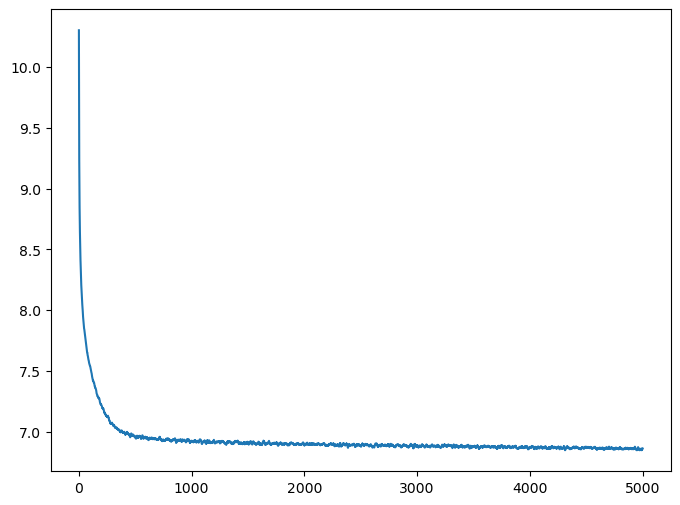

In [20]:
NF_kwargs = {"flow_type":"NSRATQUAD","tail_bound":3.2,"hidden_features":512,
             "num_layers":1,"num_bins":30,"num_blocks_per_layer":10,"tails":"linear",
            "dropout":0.0,"residual":True}
flow_rd = qrnn.make_flow(rd_train.shape[1],num_context=0,kwargs=NF_kwargs,perm=False,base_dist=None)
bs = 10000
n_epoch = 100
flow_rd = qrnn.train_flow(flow_rd,rd_train,context=None,n_epoch=n_epoch,lr=1e-3,bs=bs,
                          wd=0.0,patience=-1,n_avg=100,anneal=True)

In [21]:
samples = []
flow_rd = flow_rd.to(device)
with torch.no_grad():
    for i in range(50):
        samples.append(flow_rd.sample(10000).detach().cpu().numpy())
samples = np.concatenate(samples,axis=0)

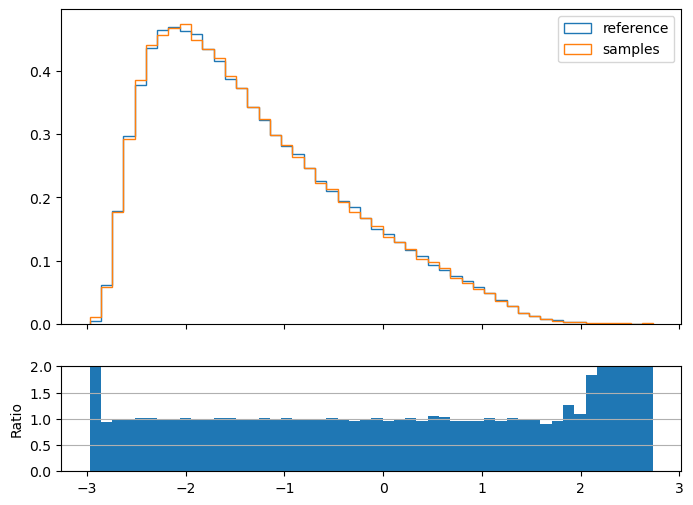

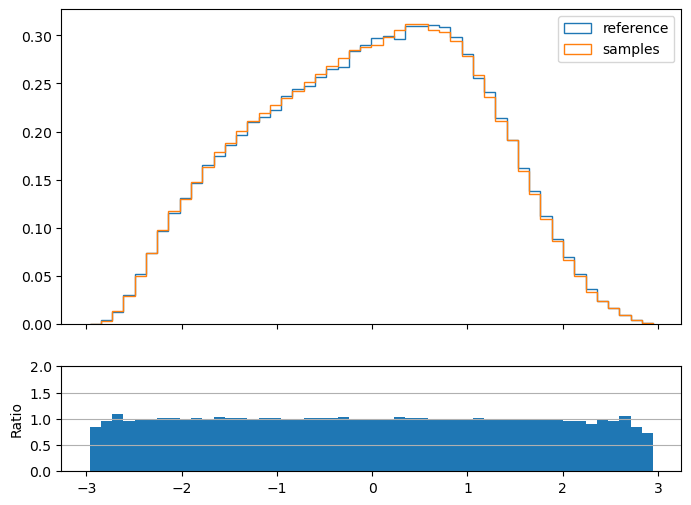

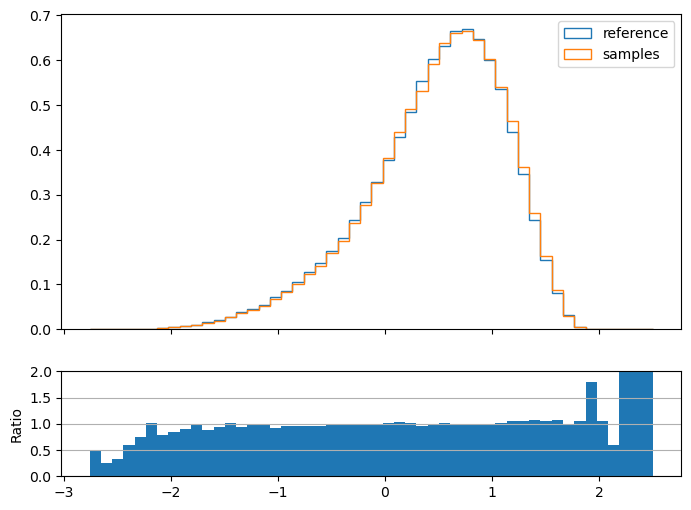

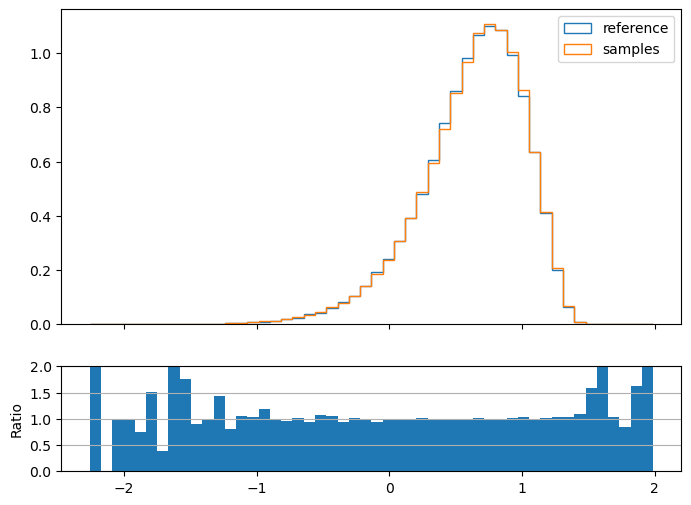

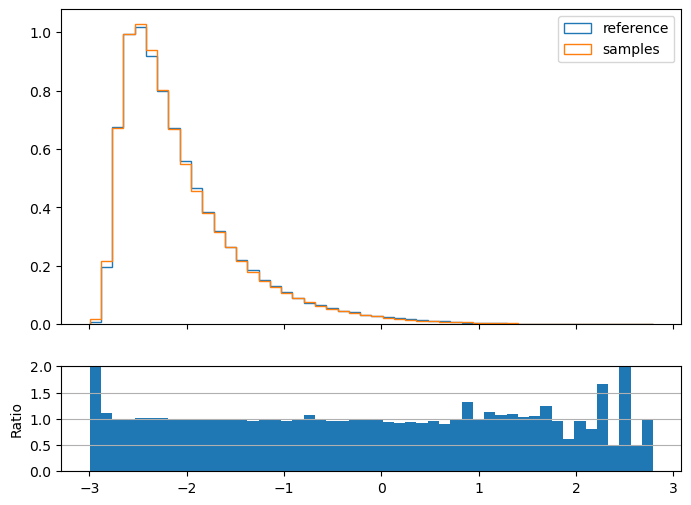

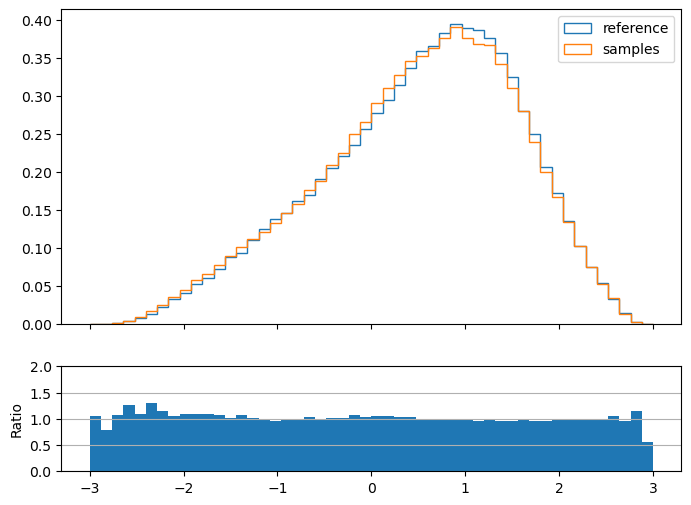

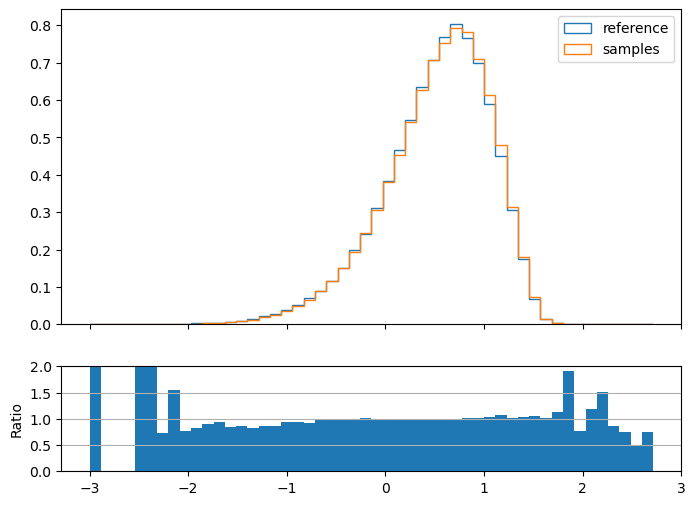

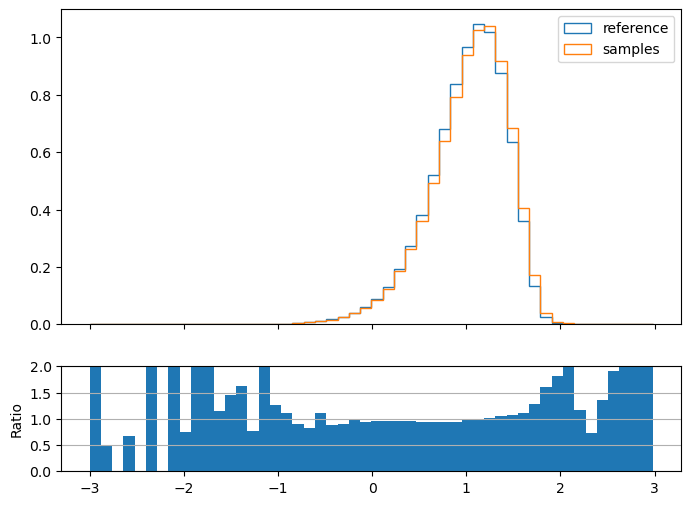

In [24]:
for i in range(samples.shape[1]):
    qrnn.plotPair(rd_test[:,i],samples[:,i],bins=50,saveName="",save=False,log=False,ylim=[0,2])

In [20]:
samples.shape

(10000, 80)